# CICCADA - Powerwall Telemetry Data Quality Assessment

This notebook performs a structured data quality assessment of the Tesla Powerwall fleet telemetry data (`all_data`).  
It assumes `all_data` has already been loaded as a single concatenated DataFrame with a `region` column (`ausnet`, `cpu`, `sapn`).

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
# Load data
# If the combined parquet data was saved earlier, use this:
BASE = Path('../../../CICCADA - Data/Tesla/datatank_telemetry_UNSW')
all_data = pd.read_parquet(BASE / 'combined_tesla_telemetry.parquet')

## 2. Schema & Basic Statistics

In [3]:
# Dtypes
print("=== Dtypes ===")
print(all_data.dtypes)

print("\n=== Descriptive statistics (numeric columns) ===")
all_data.describe().T

=== Dtypes ===
pseudonym                                category
timestamp                          datetime64[ns]
grid_connected_status                     float64
solar_reactive_power                      float64
battery_inverter_reactive_power           float64
battery_inverter_real_power               float64
AC_voltage                                float64
battery_target_power                      float64
solar_instant_power                       float64
solar_real_power_limit                    float64
site_energy_exported                      float64
site_energy_imported                      float64
solar_to_battery_energy                   float64
solar_to_load_energy                      float64
battery_target_reactive_power             float64
csip_opmod_exp_lim                        float64
region                                   category
csip_opmod_gen_lim_w                      float64
csip_set_grad_w                           float64
dtype: object

=== Descriptive stat

,count,mean,min,25%,50%,75%,max,std
timestamp,42749699,2025-09-18 17:44:40.570670080,2024-12-09 00:00:00,2025-06-24 04:39:00,2025-10-03 11:34:00,2025-12-20 14:58:00,2026-03-09 23:59:00,NaN
grid_connected_status,42524902.000,50.014,46.660,49.980,50.000,50.020,61.860,0.307
solar_reactive_power,42524933.000,51.554,-6368.000,0.000,0.000,0.000,12124.000,429.510
battery_inverter_reactive_power,42516400.000,-918.408,-10480.000,-1520.000,-680.000,0.000,7040.000,1081.591
battery_inverter_real_power,42516400.000,1273.126,-9880.000,120.000,400.000,1520.000,19840.000,2202.561
AC_voltage,42516398.000,240.943,0.000,238.400,241.600,244.200,279.200,6.282
battery_target_power,42516397.000,-8.771,-11480.000,30.000,160.000,440.000,21500.000,1474.847
solar_instant_power,42516400.000,1411.977,-485.000,0.000,5.000,1950.000,17095.000,2398.102
solar_real_power_limit,42479033.000,1386.421,-100.000,0.000,8.000,1998.000,8091.000,2247.560
site_energy_exported,42466681.000,2323027.703,-1.000,1301723.000,2236307.000,3210204.000,7823618.000,1318736.875


=== Global Null Summary ===
                                 null_count  null_pct
csip_opmod_gen_lim_w               42749673   100.000
csip_set_grad_w                    35017434    81.910
solar_to_load_energy               34246920    80.110
solar_to_battery_energy            34246920    80.110
csip_opmod_exp_lim                  5614330    13.130
site_energy_imported                 283018     0.660
site_energy_exported                 283018     0.660
battery_target_reactive_power        283216     0.660
solar_real_power_limit               270666     0.630
battery_inverter_real_power          233299     0.550
battery_target_power                 233302     0.550
AC_voltage                           233301     0.550
battery_inverter_reactive_power      233299     0.550
solar_instant_power                  233299     0.550
grid_connected_status                224797     0.530
solar_reactive_power                 224766     0.530
pseudonym                                 0     0.000


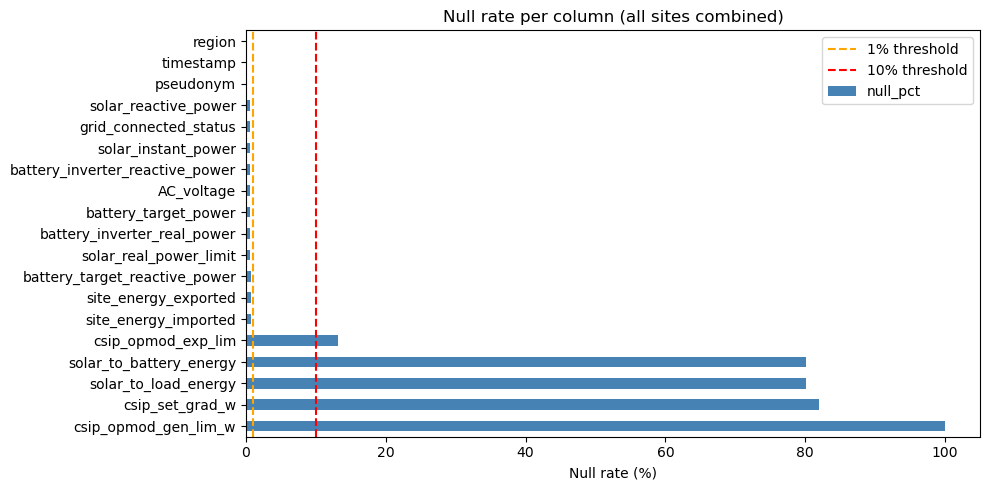

In [4]:
# Global null counts and rates
null_counts = all_data.isnull().sum()
null_rates  = (null_counts / len(all_data) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_rates
}).sort_values('null_pct', ascending=False)

print("=== Global Null Summary ===")
print(null_summary.to_string())

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
null_summary['null_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Null rate (%)')
ax.set_title('Null rate per column (all sites combined)')
ax.axvline(1,  color='orange', linestyle='--', label='1% threshold')
ax.axvline(10, color='red',    linestyle='--', label='10% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Temporal Integrity
Data is expected at exactly 1-minute (60-second) intervals per site.  
We check for: missing rows, duplicate timestamps, and non-60s gaps.

In [5]:
# Expected date range
ts_min = all_data['timestamp'].min()
ts_max = all_data['timestamp'].max()
expected_index = pd.date_range(ts_min, ts_max, freq='1min')
expected_rows_per_site = len(expected_index)
print(f"Expected rows per site (if no gaps): {expected_rows_per_site:,}")

Expected rows per site (if no gaps): 656,640


In [6]:
# Duplicate timestamps per site
dupes = (
    all_data
    .groupby('pseudonym')
    .apply(lambda g: g.duplicated(subset='timestamp').sum())
    .rename('duplicate_timestamps')
)
print("=== Duplicate timestamps per site ===")
print(dupes[dupes > 0].to_string() if (dupes > 0).any() else "No duplicates found.")

=== Duplicate timestamps per site ===
No duplicates found.


In [7]:
# Time delta distribution
# Compute per-site time deltas
all_data['dt_seconds'] = (
    all_data
    .groupby('pseudonym')['timestamp']
    .diff()
    .dt.total_seconds()
)

dt_counts = all_data['dt_seconds'].value_counts(dropna=True).head(15)
print("=== Top 15 time delta values (seconds) ===")
print(dt_counts.to_string())

# Pct of intervals that are exactly 60s
non_null_deltas = all_data['dt_seconds'].dropna()
pct_60s = (non_null_deltas == 60).mean() * 100
print(f"\nIntervals exactly 60s: {pct_60s:.2f}%")

=== Top 15 time delta values (seconds) ===
dt_seconds
60.000        42748489
120.000            767
180.000            238
7080.000            31
7140.000            26
240.000             18
300.000              8
360.000              4
480.000              2
2760.000             1
600.000              1
321180.000           1
85440.000            1
840.000              1
10620.000            1

Intervals exactly 60s: 100.00%


=== Sites with <99% temporal completeness ===
           actual_rows  expected_rows  missing_rows  completeness_pct
pseudonym                                                            
SN098            71892         656640        584748            10.950
SN049           203036         656640        453604            30.920
SN050           203024         656640        453616            30.920
SN040           206294         656640        450346            31.420
SN086           207038         656640        449602            31.530
SN027           213112         656640        443528            32.450
SN032           213110         656640        443530            32.450
SN031           213110         656640        443530            32.450
SN035           213108         656640        443532            32.450
SN036           213111         656640        443529            32.450
SN037           213107         656640        443533            32.450
SN038           213112         656640       

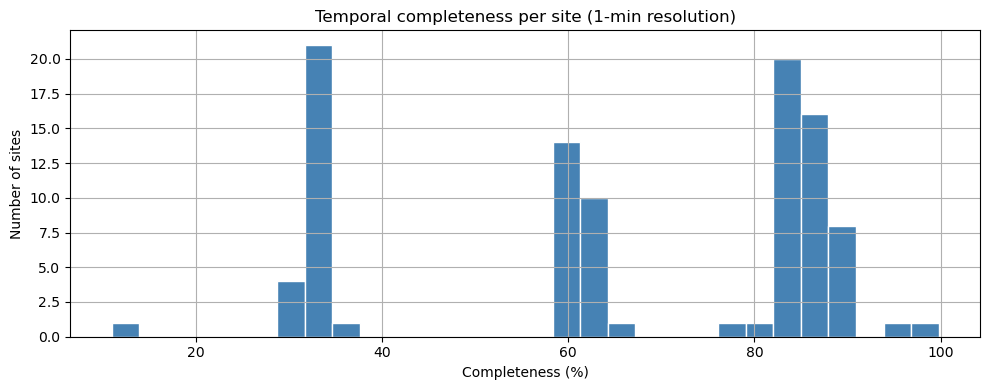

In [8]:
# Per-site: actual row count vs expected, and missing row count
site_row_counts = all_data.groupby('pseudonym').size().rename('actual_rows')
site_temporal = site_row_counts.to_frame()
site_temporal['expected_rows'] = expected_rows_per_site
site_temporal['missing_rows']  = site_temporal['expected_rows'] - site_temporal['actual_rows']
site_temporal['completeness_pct'] = (site_temporal['actual_rows'] / site_temporal['expected_rows'] * 100).round(2)

print("=== Sites with <99% temporal completeness ===")
low_completeness = site_temporal[site_temporal['completeness_pct'] < 99]
print(low_completeness.sort_values('completeness_pct').to_string() if len(low_completeness) else "All sites ≥99% complete.")

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))
site_temporal['completeness_pct'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Completeness (%)')
ax.set_ylabel('Number of sites')
ax.set_title('Temporal completeness per site (1-min resolution)')
plt.tight_layout()
plt.show()

In [9]:
# Large gaps: find intervals > 60 min
large_gaps = all_data[all_data['dt_seconds'] > 3600][['pseudonym', 'timestamp', 'dt_seconds']].copy()
large_gaps['gap_hours'] = (large_gaps['dt_seconds'] / 3600).round(1)
print(f"=== Large gaps (>1 hour): {len(large_gaps)} instances across {large_gaps['pseudonym'].nunique()} sites ===")
print(large_gaps.sort_values('gap_hours', ascending=False).head(20).to_string())

=== Large gaps (>1 hour): 65 instances across 6 sites ===
         pseudonym           timestamp  dt_seconds  gap_hours
11064428     SN014 2026-02-27 08:23:00  321180.000     89.200
11064434     SN014 2026-02-28 08:17:00   85440.000     23.700
15191600     SN025 2025-10-16 02:30:00   17160.000      4.800
18643814     SN056 2025-10-14 04:20:00   11160.000      3.100
13203793     SN020 2025-09-15 02:45:00   10620.000      3.000
35578935     SN086 2025-07-07 03:43:00    8280.000      2.300
3230105      SN040 2026-03-05 08:07:00    7140.000      2.000
3230106      SN040 2026-03-05 10:05:00    7080.000      2.000
3230107      SN040 2026-03-05 12:04:00    7140.000      2.000
3230114      SN040 2026-03-06 01:53:00    7080.000      2.000
3230115      SN040 2026-03-06 03:51:00    7080.000      2.000
3230108      SN040 2026-03-05 14:02:00    7080.000      2.000
3230109      SN040 2026-03-05 16:01:00    7140.000      2.000
3230110      SN040 2026-03-05 17:59:00    7080.000      2.000
3230111     

## 4. Column-by-Column Quality Assessment

Each subsection covers one or more related columns.

In [10]:
all_data

,pseudonym,timestamp,grid_connected_status,solar_reactive_power,battery_inverter_reactive_power,battery_inverter_real_power,AC_voltage,battery_target_power,solar_instant_power,solar_real_power_limit,site_energy_exported,site_energy_imported,solar_to_battery_energy,solar_to_load_energy,battery_target_reactive_power,csip_opmod_exp_lim,region,csip_opmod_gen_lim_w,csip_set_grad_w,dt_seconds
0,SN026,2025-10-13 00:00:00,49.980,0.000,-2080.000,6680.000,245.400,-5100.000,11640.000,8091.000,727746.000,702000.000,676932.375,687775.000,0.000,NaN,ausnet,NaN,NaN,NaN
1,SN026,2025-10-13 00:01:00,49.990,0.000,-1920.000,6720.000,245.200,-5020.000,11675.000,8091.000,727829.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
2,SN026,2025-10-13 00:02:00,49.960,0.000,-2040.000,6800.000,245.800,-5050.000,11805.000,8091.000,727916.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
3,SN026,2025-10-13 00:03:00,49.970,0.000,-560.000,640.000,240.800,-4020.000,4780.000,4980.000,727996.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
4,SN026,2025-10-13 00:04:00,49.990,0.000,-1880.000,7040.000,244.600,-5020.000,12060.000,8091.000,728072.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42749694,SN100,2026-03-08 23:55:00,49.970,-4.000,-1040.000,-1160.000,242.400,-1080.000,0.000,3.000,2600703.000,2561260.000,2289154.500,1445948.125,0.000,5000.000,sapn,NaN,28.001,60.000
42749695,SN100,2026-03-08 23:56:00,49.990,11.000,-1320.000,-1280.000,243.200,-1100.000,0.000,2.000,2600722.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000
42749696,SN100,2026-03-08 23:57:00,49.990,-5.000,-1240.000,-1200.000,243.000,-1140.000,0.000,2.000,2600741.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000
42749697,SN100,2026-03-08 23:58:00,50.030,12.000,-1160.000,-1200.000,242.800,-1140.000,0.000,3.000,2600760.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000


### 4.1 `grid_connected_status`

**Expected (per manual - page 64, table 8):** Text — `"Grid Connected"` or `"Grid Disconnected"`  
**Observed:** Float values ~49.97 to 50.02  
**Hypothesis:** This column is potentially **grid frequency (Hz)**, mislabelled or incorrectly mapped in the data pipeline. 
The expected true grid status signal should be `grid_connected_status` (text), but what is present resembles `grid_frequency` (Hz).

dtype: float64
Null count: 224,797

Descriptive stats:
count   42524902.000
mean          50.014
std            0.307
min           46.660
25%           49.980
50%           50.000
75%           50.020
max           61.860
Name: grid_connected_status, dtype: float64

Sample unique values (first 20 sorted):
[np.float64(46.65999984741211), np.float64(46.66999816894531), np.float64(46.68000030517578), np.float64(46.689998626708984), np.float64(46.70000076293945), np.float64(46.709999084472656), np.float64(46.720001220703125), np.float64(46.72999954223633), np.float64(46.7400016784668), np.float64(46.75), np.float64(46.7599983215332), np.float64(46.77000045776367), np.float64(46.779998779296875), np.float64(46.790000915527344), np.float64(46.79999923706055), np.float64(46.810001373291016), np.float64(46.81999969482422), np.float64(46.83000183105469), np.float64(46.84000015258789), np.float64(46.849998474121094)]


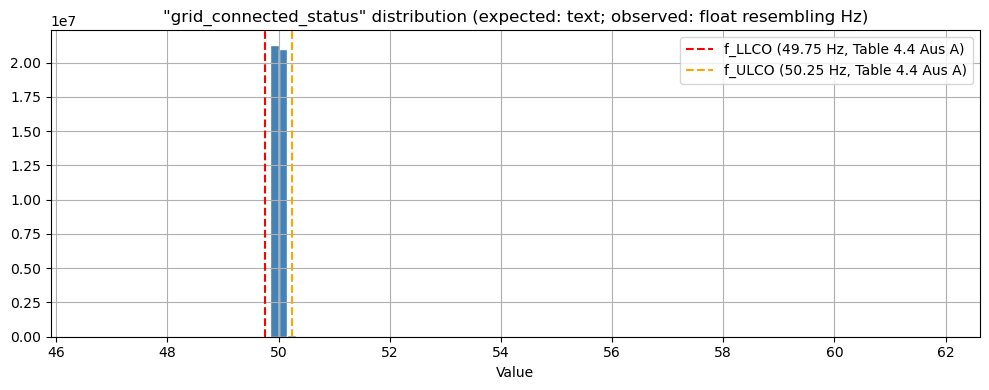


[If treated as Hz] Values <49.75 Hz (below f_LLCO, Table 4.4 Aus A): 0.009%
[If treated as Hz] Values >50.25 Hz (above f_ULCO, Table 4.4 Aus A): 0.154%
[If treated as Hz] Values <47 Hz (trip zone, Table 4.2 Aus A): 0.0004%
[If treated as Hz] Values >52 Hz (trip zone, Table 4.2 Aus A): 0.1208%


In [11]:
col = 'grid_connected_status'

print(f"dtype: {all_data[col].dtype}")
print(f"Null count: {all_data[col].isnull().sum():,}")
print(f"\nDescriptive stats:")
print(all_data[col].describe())

print(f"\nSample unique values (first 20 sorted):")
print(sorted(all_data[col].dropna().unique())[:20])

# Visualise distribution
fig, ax = plt.subplots(figsize=(10, 4))
all_data[col].dropna().hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(49.75, color='red',    linestyle='--', label='f_LLCO (49.75 Hz, Table 4.4 Aus A)')
ax.axvline(50.25, color='orange', linestyle='--', label='f_ULCO (50.25 Hz, Table 4.4 Aus A)')
ax.set_xlabel('Value')
ax.set_title(f'"{col}" distribution (expected: text; observed: float resembling Hz)')
ax.legend()
plt.tight_layout()
plt.show()

# If it IS frequency: how often is it out of the AS/NZS 4777.2 normal operating band (49–51 Hz)?
# Check Table 4.4. from AS/NZS 4777.2:2020 (page 34)
if all_data[col].between(45, 55).mean() > 0.99:
    out_of_band = all_data[col].dropna()
    pct_below = (out_of_band < 49.75).mean() * 100
    pct_above = (out_of_band > 50.25).mean() * 100
    print(f"\n[If treated as Hz] Values <49.75 Hz (below f_LLCO, Table 4.4 Aus A): {pct_below:.3f}%")
    print(f"[If treated as Hz] Values >50.25 Hz (above f_ULCO, Table 4.4 Aus A): {pct_above:.3f}%")
    # Trip thresholds — Table 4.2 (Passive anti-islanding frequency limits, Aus A)
    print(f"[If treated as Hz] Values <47 Hz (trip zone, Table 4.2 Aus A): {(out_of_band < 47.0).mean()*100:.4f}%")
    print(f"[If treated as Hz] Values >52 Hz (trip zone, Table 4.2 Aus A): {(out_of_band > 52.0).mean()*100:.4f}%")

### 4.2 `AC_voltage`

**Expected:** AC voltage at inverter terminals (V)  
**Nominal:** 230 V (single-phase Australian standard)  
**Plausible range per AS/NZS 4777.2 (Australia A defaults):**
- **VV1 = 207 V** - lower Volt-VAr onset (reactive power supply begins)
- **VV2 = 220 V** - lower Volt-VAr deadband edge (reactive power → 0)
- **VV3 = 240 V** - upper Volt-VAr deadband edge (reactive power absorption begins)
- **VW1 = 253 V** - Volt-Watt onset (active power curtailment starts here, not 235 V)
- **VV4 = 258 V** - upper Volt-VAr onset (full reactive absorption)
- **VW2 = 260 V** - Volt-Watt ramp end (output capped at 20% of rated above here)

count   42516398.000
mean         240.943
std            6.282
min            0.000
25%          238.400
50%          241.600
75%          244.200
max          279.200
Name: AC_voltage, dtype: float64

Null count: 233,301

=== Voltage band breakdown ===
  Below 180 V (below Volt-VAr VV1 allowed range): 12,471 rows (0.029%)
  180-207 V (Volt-VAr reactive supply zone, below VV1): 269 rows (0.001%)
  207-220 V (Volt-VAr transition, VV1 to VV2): 28,660 rows (0.067%)
  220-240 V (normal/unity PF zone, VV2 to VV3): 15,449,136 rows (36.337%)
  240-253 V (Volt-VAr absorbing zone, VV3 to VW1): 27,522,807 rows (64.735%)
  253-260 V (Volt-Watt active ramp, VW1 to VW2): 175,546 rows (0.413%)
  Above 260 V (above VW2 — output capped at 20%): 292 rows (0.001%)


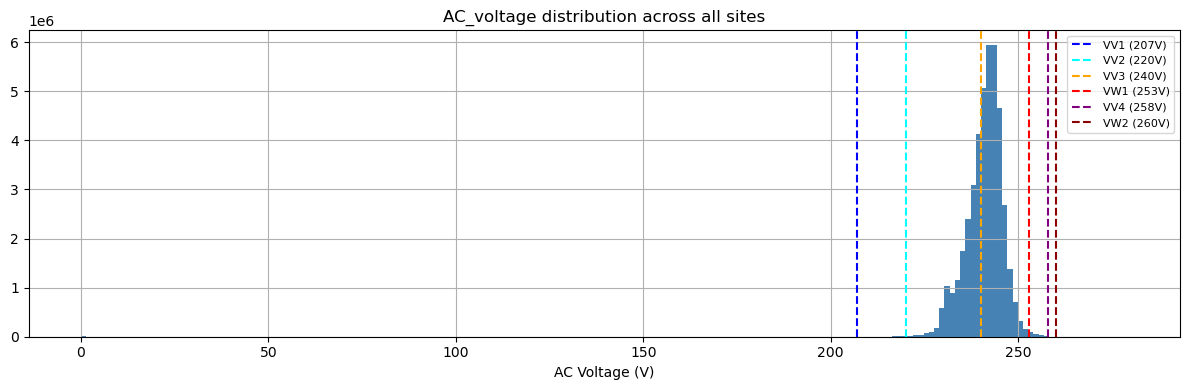

In [ ]:
col = 'AC_voltage'

print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,}")

v = all_data[col].dropna()

# Threshold analysis (using Australia A for now)
thresholds = [
    (v < 180,            'Below 180 V (below Volt-VAr VV1 allowed range)'),
    (v.between(180, 207), '180-207 V (Volt-VAr reactive supply zone, below VV1)'),
    (v.between(207, 220), '207-220 V (Volt-VAr transition, VV1 to VV2)'),
    (v.between(220, 240), '220-240 V (normal/unity PF zone, VV2 to VV3)'),
    (v.between(240, 253), '240-253 V (Volt-VAr absorbing zone, VV3 to VW1)'),
    (v.between(253, 260), '253-260 V (Volt-Watt active ramp, VW1 to VW2)'),
    (v > 260,            'Above 260 V (above VW2 — output capped at 20%)'),
]
print("\n=== Voltage band breakdown ===")
for mask, label in thresholds:
    print(f"  {label}: {mask.sum():,} rows ({mask.mean()*100:.3f}%)")

# Distribution
fig, ax = plt.subplots(figsize=(12, 4))
v.hist(bins=200, ax=ax, color='steelblue', edgecolor='none')
for xval, label, colour in [
    (207, 'VV1 (207V)',  'blue'),
    (220, 'VV2 (220V)',  'cyan'),
    (240, 'VV3 (240V)',  'orange'),
    (253, 'VW1 (253V)',  'red'),
    (258, 'VV4 (258V)',  'purple'),
    (260, 'VW2 (260V)',  'darkred'),
]:
    ax.axvline(xval, linestyle='--', color=colour, label=label)
ax.set_xlabel('AC Voltage (V)')
ax.set_title('AC_voltage distribution across all sites')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Per-site: % of time in Volt-Watt zone
voltwatt_pct = (
    all_data.dropna(subset=[col])
    .groupby('pseudonym')[col]
    .apply(lambda x: x.between(253, 260).mean() * 100)
    .rename('pct_time_voltwatt_zone')
    .sort_values(ascending=False)
)
print("\n=== Sites: % time in Volt-Watt active ramp (VW1–VW2, 253–260 V) ===")
print(voltwatt_pct.to_string())

In [ ]:
# Frozen/stuck voltage detection (same value for ≥5 consecutive minutes)
all_data['voltage_frozen'] = (
    all_data.groupby('pseudonym')[col]
    .transform(lambda x: (x.diff() == 0).rolling(5, min_periods=5).sum() == 5)
)
frozen_pct = all_data['voltage_frozen'].mean() * 100
frozen_by_site = all_data.groupby('pseudonym')['voltage_frozen'].mean().sort_values(ascending=False) * 100
print(f"Overall frozen voltage rate: {frozen_pct:.3f}%")
print("\nTop 10 sites by frozen voltage rate (%)")
print(frozen_by_site.head(10).to_string())

### 4.3 `solar_instant_power`

**Expected:** Instantaneous solar real power (W), should be ≥0 (generation only).  
**Quality checks:** negative values, nighttime solar, implausibly high values, nulls.

In [ ]:
col = 'solar_instant_power'
print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,}")

s = all_data[col].dropna()

# Negative values (metering error per manual: fails if solar < -250W > 1% of time)
neg_mask = s < -250
print(f"\nValues < -250W (manual 'Negative Solar' diagnostic threshold): {neg_mask.sum():,} ({neg_mask.mean()*100:.3f}%)")

# Any negative at all
any_neg = s < 0
print(f"Values < 0W (any negative): {any_neg.sum():,} ({any_neg.mean()*100:.3f}%)")

# Per-site negative solar rate
neg_by_site = (
    all_data.dropna(subset=[col])
    .groupby('pseudonym')[col]
    .apply(lambda x: (x < -250).mean() * 100)
    .rename('pct_negative_solar')
    .sort_values(ascending=False)
)
print("\nSites with >1% negative solar (would fail Powerhub diagnostic):")
failing = neg_by_site[neg_by_site > 1]
print(failing.to_string() if len(failing) else "None")

# Distribution (excluding zeros for clarity)
fig, ax = plt.subplots(figsize=(10, 4))
s[s != 0].hist(bins=200, ax=ax, color='gold', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', label='Zero')
ax.set_xlabel('solar_instant_power (W)')
ax.set_title('Solar instant power distribution (non-zero values)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 `solar_real_power_limit`

**Expected:** Maximum allowed solar output (W). This potentially is the **curtailment ceiling**.  
When `solar_instant_power < solar_real_power_limit`, the inverter is operating below capacity.  
When they are approximately equal, the inverter is being curtailed.  
High null rate (~80% in SN026). 
Important to understand whether nulls mean 'no limit active' or 'data unavailable'.

In [ ]:
col = 'solar_real_power_limit'
print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.1f}%)")

# Null rate per site
null_by_site = (
    all_data.groupby('pseudonym')[col]
    .apply(lambda x: x.isnull().mean() * 100)
    .rename('pct_null')
)
print("\n=== Null rate distribution across sites ===")
print(null_by_site.describe())

fig, ax = plt.subplots(figsize=(10, 4))
null_by_site.hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Null rate per site (%)')
ax.set_title(f'Per-site null rate: {col}')
plt.tight_layout()
plt.show()

# When non-null: does it equal zero? (zero limit = full curtailment command)
non_null = all_data[col].dropna()
print(f"\nNon-null values that are exactly 0W (full curtailment): {(non_null == 0).sum():,} ({(non_null == 0).mean()*100:.2f}%)")

# Curtailment proxy: rows where solar_instant_power >= solar_real_power_limit - 50W
# (i.e. actively hitting the limit)
both_present = all_data.dropna(subset=[col, 'solar_instant_power'])
curtailed = (both_present['solar_instant_power'] >= both_present[col] - 50)
print(f"\nRows where solar_instant_power ≈ solar_real_power_limit (within 50W): {curtailed.sum():,} ({curtailed.mean()*100:.2f}% of rows with both values present)")

### 4.5 `battery_inverter_real_power` and `battery_target_power`

**Sign convention (per manual):** Positive = discharge, Negative = charge  
**Quality checks:** nulls, plausibility, how closely does actual power track the target command?

In [ ]:
# See powerhub manual page 67 for battery_inverter_real_power, and page 62 for battery_target_power.

for col in ['battery_inverter_real_power', 'battery_target_power']:
    s = all_data[col].dropna()
    print(f"\n=== {col} ===")
    print(s.describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
    print(f"Charging (< 0): {(s < 0).sum():,} ({(s < 0).mean()*100:.1f}%)")
    print(f"Discharging (> 0): {(s > 0).sum():,} ({(s > 0).mean()*100:.1f}%)")
    print(f"Idle (== 0): {(s == 0).sum():,} ({(s == 0).mean()*100:.1f}%)")

# Tracking error: actual vs target
both = all_data.dropna(subset=['battery_inverter_real_power', 'battery_target_power'])
both = both.assign(
    tracking_error = both['battery_inverter_real_power'] - both['battery_target_power']
)
print("\n=== Tracking error (actual - target) ===")
print(both['tracking_error'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['battery_inverter_real_power', 'battery_target_power']):
    all_data[col].dropna().hist(bins=200, ax=ax, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Power (W)')
    ax.set_title(col)
plt.suptitle('Battery power distribution (positive=discharge, negative=charge)')
plt.tight_layout()
plt.show()

### 4.6 `solar_reactive_power` and `battery_inverter_reactive_power`

**Quality checks:** nulls, range.
Per AS/NZS 4777.2 Table 3.7 (Australia A defaults), Volt-VAr response caps reactive power at:
- **44% of rated apparent power supplying** (at VV1 = 207 V and below)
- **60% of rated apparent power absorbing** (at VV4 = 258 V and above)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['solar_reactive_power', 'battery_inverter_reactive_power']):
    s = all_data[col].dropna()
    s.hist(bins=100, ax=ax, color='coral', edgecolor='none')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_xlabel('Reactive Power (VAr)')
    ax.set_title(col)
    print(f"\n=== {col} ===")
    print(s.describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
plt.tight_layout()
plt.show()

### 4.7 `site_energy_exported` and `site_energy_imported`

**Expected:** Cumulative energy (Wh). These seem to be **running totals** (odometer-style), not interval energy.

**Quality checks:** non-monotonic (counter rollover or reset), negative values, nulls, implausible jumps.

In [ ]:
all_data[all_data['pseudonym'] == 'SN005'].plot(x='timestamp', y='site_energy_exported', figsize=(24,6))

In [ ]:
for col in ['site_energy_exported', 'site_energy_imported']:
    print(f"\n=== {col} ===")
    print(all_data[col].describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
    print(f"Negative values: {(all_data[col] < 0).sum():,}")

    # Non-monotonic check: per-site, compute diffs.
    # Negative diff = counter reset or error
    diffs = (
        all_data.dropna(subset=[col])
        .groupby('pseudonym')[col]
        .diff()
    )
    n_decreases = (diffs < -100).sum()  # allow small floating point noise
    n_big_jumps = (diffs > 1e6).sum()   # >1 MWh in one minute = likely error
    print(f"Non-monotonic drops (diff < -100 Wh): {n_decreases:,}")
    print(f"Implausible jumps (diff > 1 MWh/min): {n_big_jumps:,}")

### 4.8 `solar_to_battery_energy` and `solar_to_load_energy`

**Expected:** Energy flows (Wh). Should be ≥ 0  

In [ ]:
for col in ['solar_to_battery_energy', 'solar_to_load_energy']:
    print(f"\n=== {col} ===")
    null_by_site = all_data.groupby('pseudonym')[col].apply(lambda x: x.isnull().mean() * 100)
    print(f"Overall null rate: {all_data[col].isnull().mean()*100:.1f}%")
    print(f"Sites with 100% nulls: {(null_by_site == 100).sum()}")
    print(f"Sites with 0% nulls:   {(null_by_site == 0).sum()}")
    print(f"Sites with partial nulls: {((null_by_site > 0) & (null_by_site < 100)).sum()}")

    non_null = all_data[col].dropna()
    if len(non_null):
        print(f"Non-null describe:")
        print(non_null.describe())
        print(f"Negative values: {(non_null < 0).sum():,}")

# Are the sites with data clustered by region?
print("\n=== solar_to_battery_energy: null rate by region ===")
if 'region' in all_data.columns:
    print(all_data.groupby('region')['solar_to_battery_energy'].apply(lambda x: x.isnull().mean() * 100).rename('null_pct'))

### 4.9 `battery_target_reactive_power`

**Expected:** Reactive power command from Site Controller (VAr)  
**Quality checks:** nulls, whether it is ever non-zero (active Volt-VAr dispatch)

In [ ]:
col = 'battery_target_reactive_power'
print(all_data[col].describe())
print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
print(f"Exactly zero: {(all_data[col] == 0).sum():,} ({(all_data[col] == 0).mean()*100:.2f}%)")
nonzero = all_data[col].dropna()
nonzero = nonzero[nonzero != 0]
print(f"Non-zero values: {len(nonzero):,}")
if len(nonzero):
    print(nonzero.describe())

### 4.10 `csip_opmod_exp_lim`

**Expected:** CSIP-AUS export limit (W) active on this site.
This is the export limit dispatched via the Common Smart Inverter Profile (Australia).  
When non-null and non-zero, an export limit is active.  
When zero, full curtailment has been commanded.  
**When null:** the CSIP-AUS connection may not be active, or the field was not transmitted.
**Note:** Can't find this parameter in the powerhub manual

In [ ]:
col = 'csip_opmod_exp_lim'
print(all_data[col].describe())
print(f"\nNull: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
print(f"Zero (full curtailment commanded): {(all_data[col] == 0).sum():,}")

non_null = all_data[col].dropna()
print(f"\nValue counts (top 20):")
print(non_null.value_counts().head(20).to_string())

# Null rate per site
null_by_site = all_data.groupby('pseudonym')[col].apply(lambda x: x.isnull().mean() * 100).rename('null_pct')
print("\n=== Null rate distribution across sites ===")
print(null_by_site.describe())

# Are nulls clustered in time? (suggests CSIP not yet deployed at start of dataset)
all_data['csip_null'] = all_data[col].isnull()
csip_null_over_time = (
    all_data.set_index('timestamp')
    .resample('1D')['csip_null']
    .mean() * 100
)
fig, ax = plt.subplots(figsize=(12, 4))
csip_null_over_time.plot(ax=ax, color='steelblue')
ax.set_ylabel('Null rate (%)')
ax.set_title('csip_opmod_exp_lim daily null rate (all sites)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# When non-null and > 0: distribution of limit values
active_limits = non_null[non_null > 0]
if len(active_limits):
    print(f"\nActive export limits (>0W): {len(active_limits):,} rows")
    print(active_limits.describe())

## 5. Cross-Column Physical Plausibility
These checks test whether combinations of columns make physical sense.

In [ ]:
# Check 1: Battery discharging AND exporting > limit
# If csip_opmod_exp_lim is active, site_energy_exported shouldn't be growing
# faster than the limit permits. This is a rough proxy — exact check needs
# interval energy, not cumulative.
# Here we flag rows where battery is discharging (>0) and csip limit is 0
# (should mean no export allowed).
check1 = all_data[
    (all_data['battery_inverter_real_power'] > 100) &  # battery discharging
    (all_data['csip_opmod_exp_lim'] == 0)              # zero export limit active
]
print(f"Check 1 — Battery discharging while CSIP export limit = 0: {len(check1):,} rows ({len(check1)/len(all_data)*100:.2f}%)")
# Note: this isn't necessarily wrong (battery could be serving load, not exporting)
# but worth reviewing.

In [ ]:
# Check 2: Solar exceeds its own limit
# solar_instant_power should not significantly exceed solar_real_power_limit
both = all_data.dropna(subset=['solar_instant_power', 'solar_real_power_limit'])
over_limit = both[both['solar_instant_power'] > both['solar_real_power_limit'] + 100]  # 100W tolerance
print(f"Check 2 — solar_instant_power > solar_real_power_limit + 100W: {len(over_limit):,} rows ({len(over_limit)/len(both)*100:.2f}% of rows with both present)")
if len(over_limit):
    print("Example rows:")
    print(over_limit[['pseudonym', 'timestamp', 'solar_instant_power', 'solar_real_power_limit']].head(10).to_string())

In [ ]:
# Check 3: Negative home load proxy
# The Powerhub diagnostic 'Negative Home Load' fires if:
# load_real_power < -100W more than 1% of the time.
# We don't have load_real_power directly, but we can approximate:
# Approx load = solar - battery_discharge + grid_import
# (This is only possible if the sign convention is consistent)
# For now, flag if solar_to_load_energy goes negative
neg_stl = all_data[all_data['solar_to_load_energy'] < 0]
print(f"Check 3 - solar_to_load_energy < 0: {len(neg_stl):,} rows")

In [ ]:
# Check 4: Target vs actual reactive power consistency
# Reactive power target is almost always 0 — flag sites where
# actual battery_inverter_reactive_power is large when target is 0
both_rp = all_data.dropna(subset=['battery_inverter_reactive_power', 'battery_target_reactive_power'])
unexpected_reactive = both_rp[
    (both_rp['battery_target_reactive_power'] == 0) &
    (both_rp['battery_inverter_reactive_power'].abs() > 500)
]
print(f"Check 4 — Large reactive power when target is 0 (>500 VAr): {len(unexpected_reactive):,} rows")
if len(unexpected_reactive):
    print(unexpected_reactive.groupby('pseudonym').size().sort_values(ascending=False).head(10))

## 6. Per-Site Quality Summary

All quality dimensions into a single per-site summary table.

In [ ]:
numeric_cols = [
    'grid_connected_status', 'solar_reactive_power', 'battery_inverter_reactive_power',
    'battery_inverter_real_power', 'AC_voltage', 'battery_target_power',
    'solar_instant_power', 'solar_real_power_limit', 'site_energy_exported',
    'site_energy_imported', 'solar_to_battery_energy', 'solar_to_load_energy',
    'battery_target_reactive_power', 'csip_opmod_exp_lim'
]

def site_quality(g):
    n = len(g)
    row = {}
    row['n_rows'] = n
    row['completeness_pct'] = round(n / expected_rows_per_site * 100, 2)
    row['duplicate_ts'] = g.duplicated(subset='timestamp').sum()
    row['n_large_gaps'] = (g['dt_seconds'] > 3600).sum()

    for col in numeric_cols:
        null_rate = g[col].isnull().mean() * 100
        row[f'{col}_null_pct'] = round(null_rate, 1)

    # Key derived flags
# REPLACE WITH
    row['pct_voltwatt_zone']   = round(g['AC_voltage'].between(253, 260).mean() * 100, 2)  # VW1-VW2 ramp
    row['pct_above_VW1']       = round((g['AC_voltage'] > 253).mean() * 100, 2)            # any VW exposure
    row['pct_above_VW2']       = round((g['AC_voltage'] > 260).mean() * 100, 2)            
    row['pct_negative_solar']  = round((g['solar_instant_power'] < -250).mean() * 100, 3)
    row['csip_active_rows']    = (g['csip_opmod_exp_lim'].notna() & (g['csip_opmod_exp_lim'] >= 0)).sum()
    row['csip_zero_limit_rows'] = (g['csip_opmod_exp_lim'] == 0).sum()

    return pd.Series(row)

print("Computing per-site quality summary...")
site_quality_df = all_data.groupby('pseudonym').apply(site_quality)

if 'region' in all_data.columns:
    site_quality_df = site_quality_df.join(
        all_data.groupby('pseudonym')['region'].first()
    )

print("Done.")
print(f"\nQuality summary shape: {site_quality_df.shape}")
site_quality_df

In [ ]:
# Heatmap: null rates across columns and sites
null_cols = [c for c in site_quality_df.columns if c.endswith('_null_pct')]
null_heat = site_quality_df[null_cols].copy()
null_heat.columns = [c.replace('_null_pct', '') for c in null_cols]

fig, ax = plt.subplots(figsize=(16, max(8, len(null_heat) * 0.18)))
sns.heatmap(
    null_heat,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=100,
    linewidths=0.1,
    cbar_kws={'label': 'Null rate (%)'}
)
ax.set_title('Per-site null rate heatmap (each row = one battery, each column = one signal)')
ax.set_xlabel('Signal')
ax.set_ylabel('Site (pseudonym)')
plt.tight_layout()
plt.show()

In [ ]:
# Summary stats by region
if 'region' in site_quality_df.columns:
    print("=== Mean completeness and key null rates by region ===")
    key_cols = ['completeness_pct', 'csip_opmod_exp_lim_null_pct',
                'solar_real_power_limit_null_pct', 'pct_voltwatt_zone',
                'pct_above_VW1', 'pct_above_VW2']
    key_cols = [c for c in key_cols if c in site_quality_df.columns]
    print(site_quality_df.groupby('region')[key_cols].mean().round(2).to_string())

## 7. Flags & Export

In [ ]:
# Assign pass/flag status on key dimensions
flags = site_quality_df[['completeness_pct']].copy()
if 'region' in site_quality_df.columns:
    flags['region'] = site_quality_df['region']

flags['FLAG_low_completeness']       = site_quality_df['completeness_pct'] < 95
flags['FLAG_has_duplicates']         = site_quality_df['duplicate_ts'] > 0
flags['FLAG_has_large_gaps']         = site_quality_df['n_large_gaps'] > 0
flags['FLAG_csip_mostly_null']       = site_quality_df['csip_opmod_exp_lim_null_pct'] > 50
flags['FLAG_solar_limit_mostly_null']= site_quality_df['solar_real_power_limit_null_pct'] > 80
flags['FLAG_negative_solar']         = site_quality_df['pct_negative_solar'] > 1
flags['FLAG_voltwatt_exposure']   = site_quality_df['pct_above_VW1'] > 5   # >5% time in VW zone
flags['FLAG_over_voltage']        = site_quality_df['pct_above_VW2'] > 1   # >1% time above VW2
flags['FLAG_solar_energy_null']      = site_quality_df['solar_to_battery_energy_null_pct'] > 50

flags['n_flags'] = flags[[c for c in flags.columns if c.startswith('FLAG_')]].sum(axis=1)

print("=== Quality flag summary ===")
print(flags[[c for c in flags.columns if c.startswith('FLAG_')]].sum().rename('sites_flagged'))

print("\n=== Sites with 3+ flags ===")
print(flags[flags['n_flags'] >= 3].sort_values('n_flags', ascending=False).to_string())

In [ ]:
# Export
# OUTPUT_DIR = Path('.')  # change as needed

# site_quality_df.to_csv(OUTPUT_DIR / 'site_quality_summary.csv')
# flags.to_csv(OUTPUT_DIR / 'site_quality_flags.csv')

# print("Exported:")
# print("  site_quality_summary.csv  — full numeric quality metrics per site")
# print("  site_quality_flags.csv    — pass/fail flags per site")